In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
from catboost import CatBoostClassifier
import warnings
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
warnings.filterwarnings('ignore')
import category_encoders as ce
from pytabkit import RealMLP_TD_Classifier
from gplearn.genetic import SymbolicTransformer
import torch
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
import logging


# Data Processing

In [4]:
df = pd.read_csv("Data/cardiac_failure_processed.csv")
df.head(5)

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df = df.drop(columns=['Unnamed: 0','id'])

In [6]:
df.shape

(70000, 12)

In [7]:
df.head(5)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 6.4 MB


In [9]:
#Reduce memory 
df = df.astype({
    "age": "float32",
    "gender": "uint8",
    "height": "uint8",
    "weight": "float32",
    "ap_hi": "uint8",
    "ap_lo": "uint8",
    "cholesterol": "uint8",
    "gluc": "uint8",
    "smoke": "uint8",
    "alco": "uint8",
    "active": "uint8",
    "cardio": "uint8"
})

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float32
 1   gender       70000 non-null  uint8  
 2   height       70000 non-null  uint8  
 3   weight       70000 non-null  float32
 4   ap_hi        70000 non-null  uint8  
 5   ap_lo        70000 non-null  uint8  
 6   cholesterol  70000 non-null  uint8  
 7   gluc         70000 non-null  uint8  
 8   smoke        70000 non-null  uint8  
 9   alco         70000 non-null  uint8  
 10  active       70000 non-null  uint8  
 11  cardio       70000 non-null  uint8  
dtypes: float32(2), uint8(10)
memory usage: 1.2 MB


memory reduced -> 6.4 MB To 1.6 MB

In [11]:
df['age'].nunique()

8076

In [12]:
df.duplicated().sum()

np.int64(24)

# EDA

In [13]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.671379,1.349571,164.359229,74.205688,126.714429,82.839329,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,0.191038,0.476838,8.210126,14.395757,18.083021,18.008251,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,1.000000,55.000000,10.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.531630,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,0.689508,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,0.815254,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,2.000000,250.000000,200.000000,240.000000,254.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


As we can see, the dataset contains significant outliers.

age ---------->
age--> has 8076 unique elements


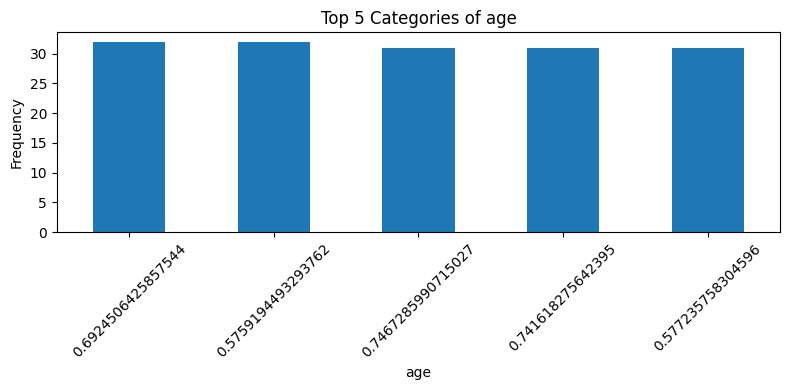

gender ---------->
gender--> has 2 unique elements


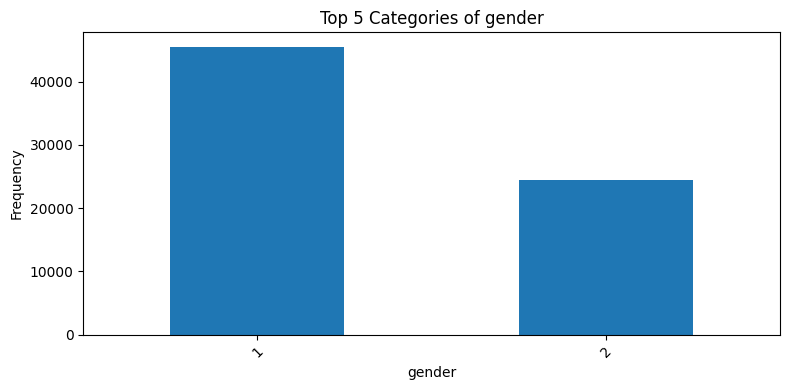

height ---------->
height--> has 109 unique elements


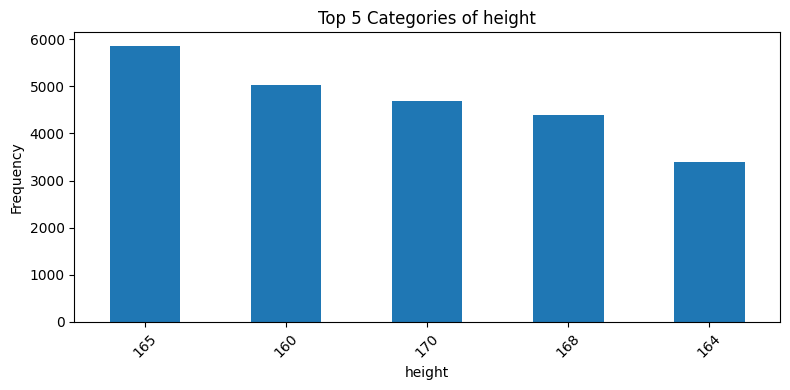

weight ---------->
weight--> has 287 unique elements


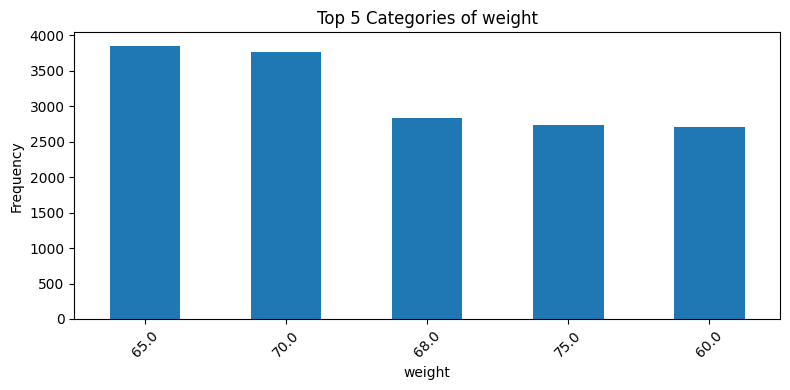

ap_hi ---------->
ap_hi--> has 131 unique elements


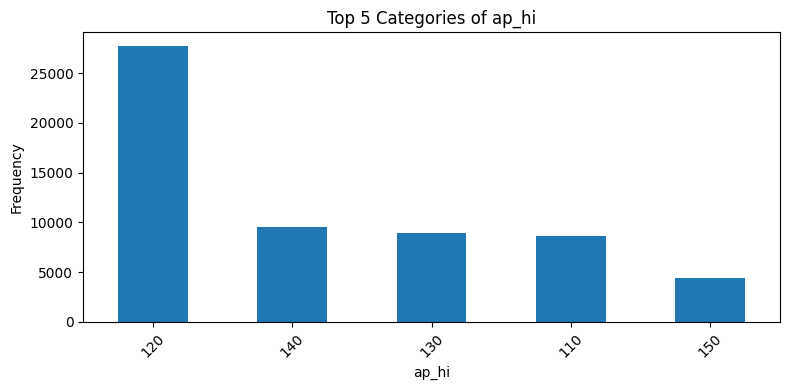

ap_lo ---------->
ap_lo--> has 128 unique elements


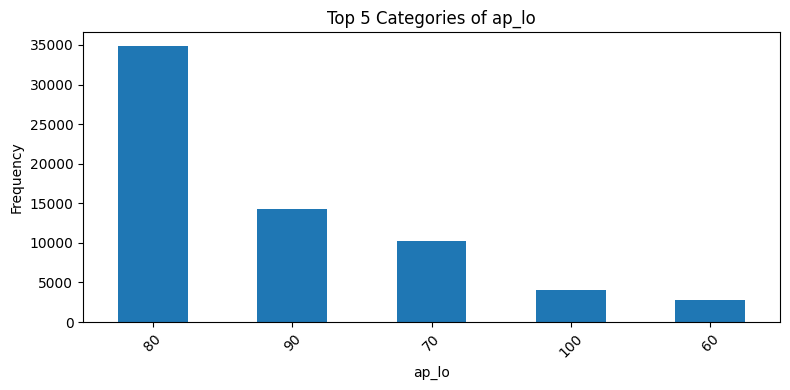

cholesterol ---------->
cholesterol--> has 3 unique elements


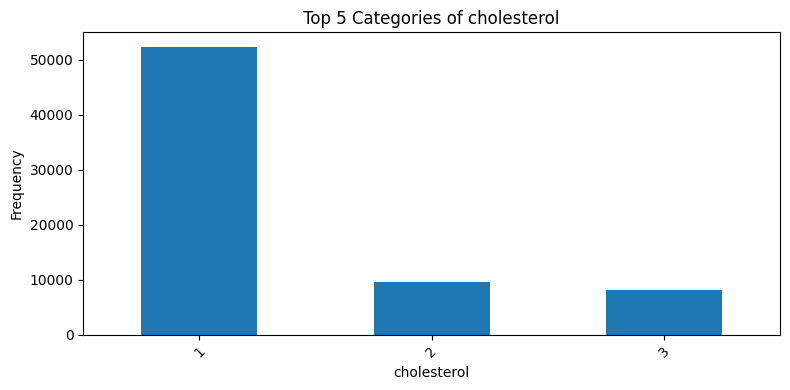

gluc ---------->
gluc--> has 3 unique elements


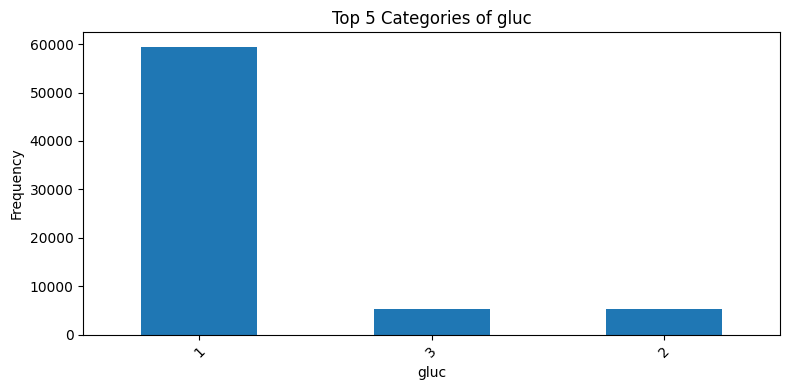

smoke ---------->
smoke--> has 2 unique elements


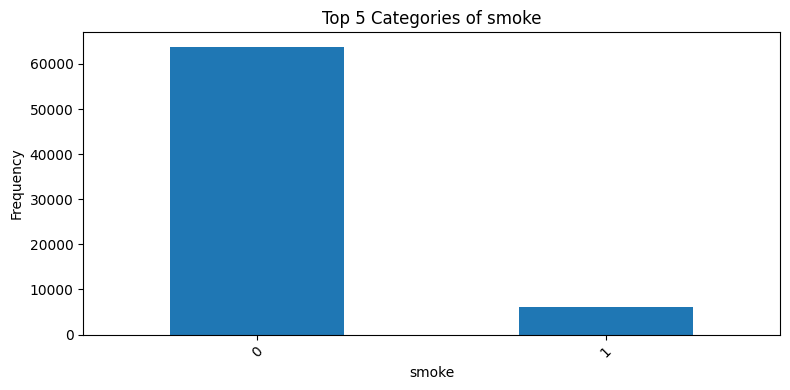

alco ---------->
alco--> has 2 unique elements


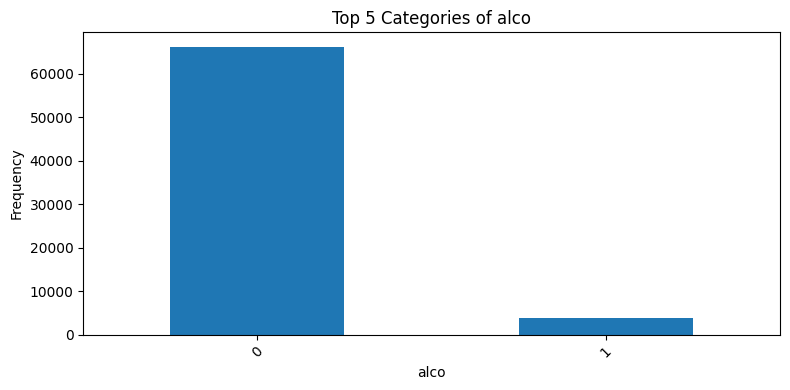

active ---------->
active--> has 2 unique elements


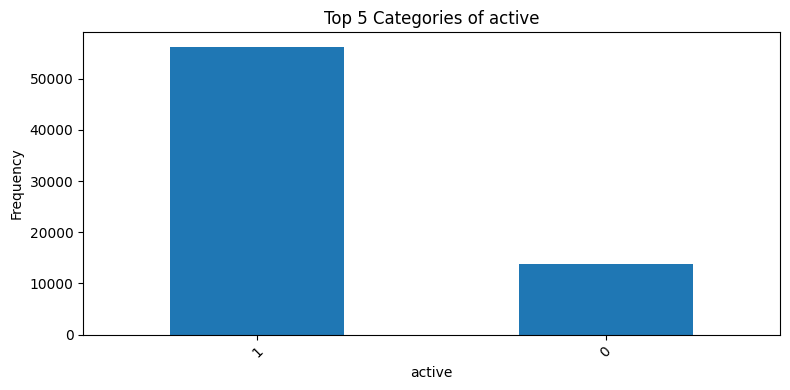

cardio ---------->
cardio--> has 2 unique elements


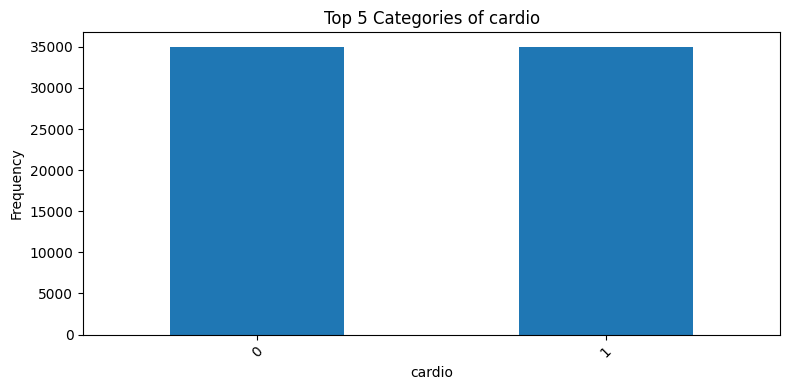

In [14]:
for col in df.columns:
    print(col + " ---------->")
    
    vc = df[col].value_counts().head(5)
    vc.plot(kind="bar", figsize=(8,4))
    
    print(f'{col}--> has {df[col].nunique()} unique elements')

    plt.title(f"Top 5 Categories of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The dataset is also unbalanced

age ---------->


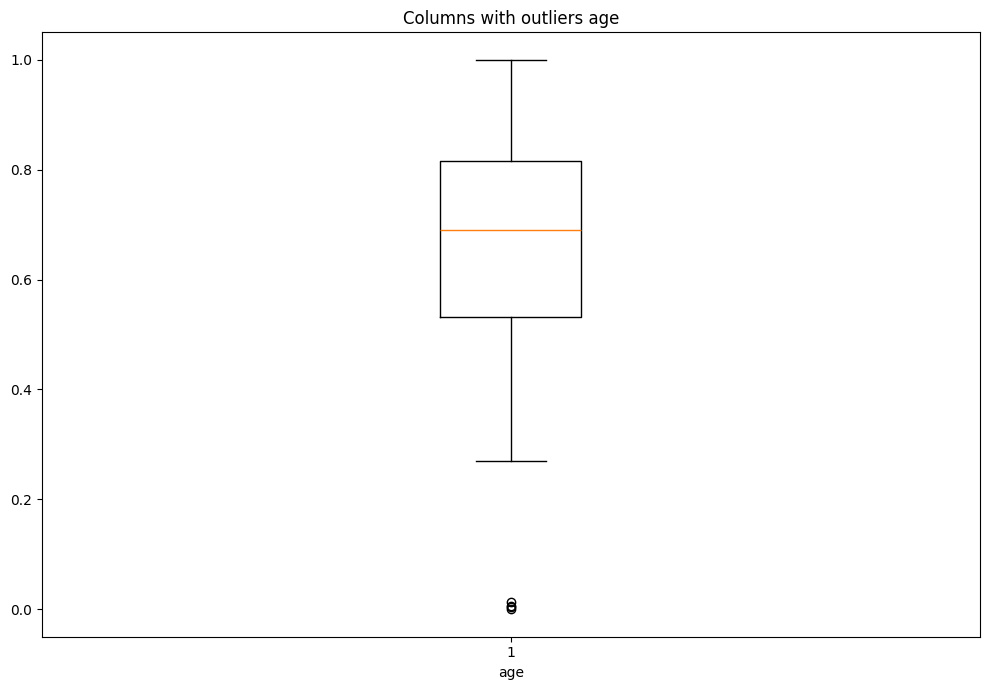

gender ---------->


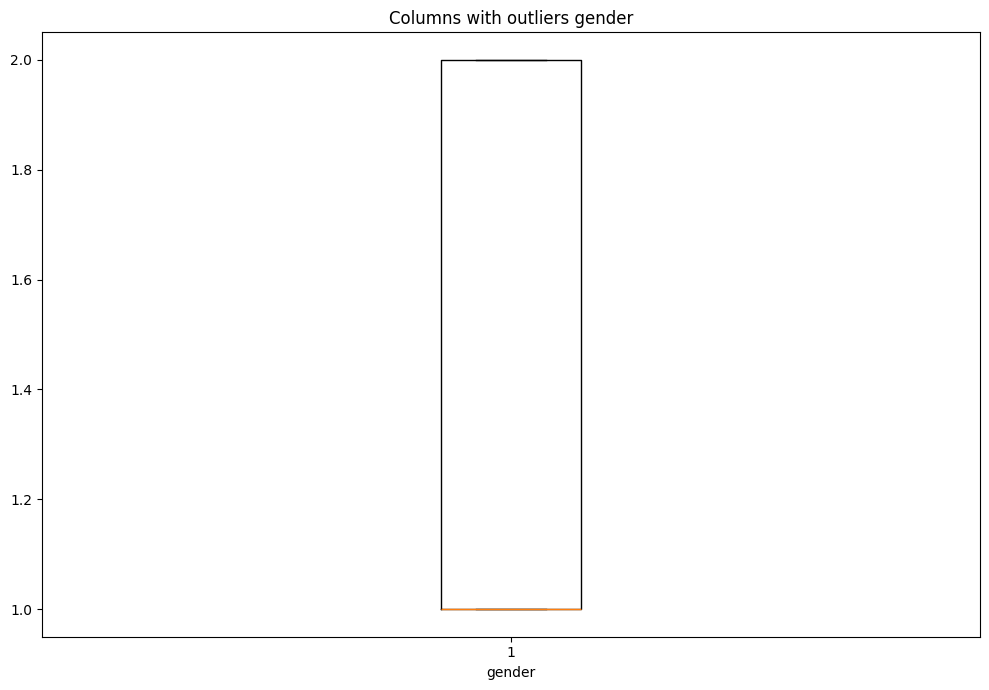

height ---------->


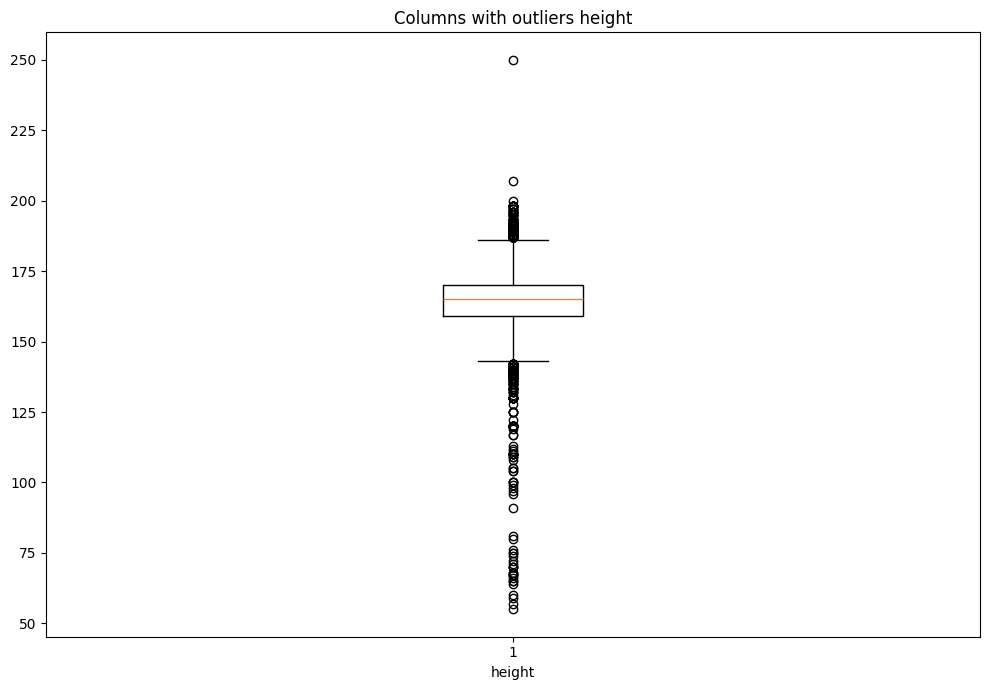

weight ---------->


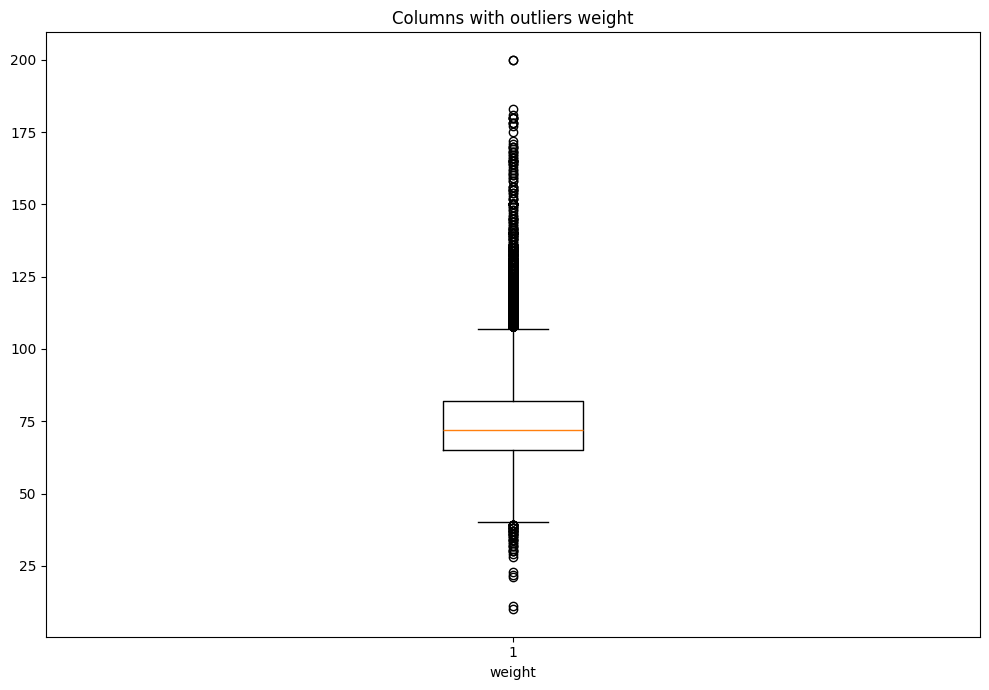

ap_hi ---------->


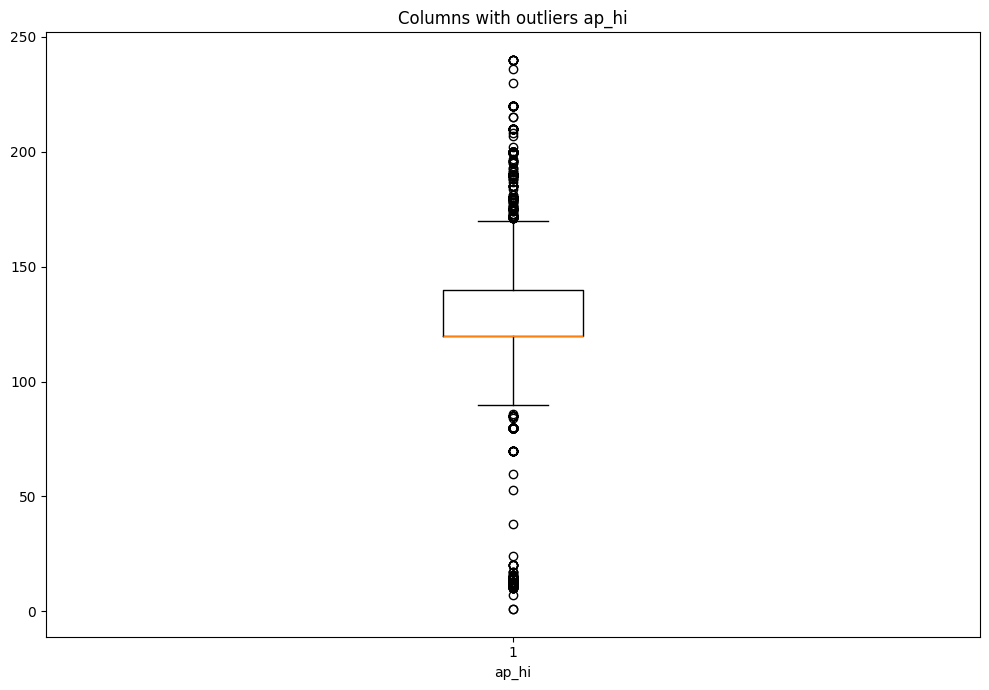

ap_lo ---------->


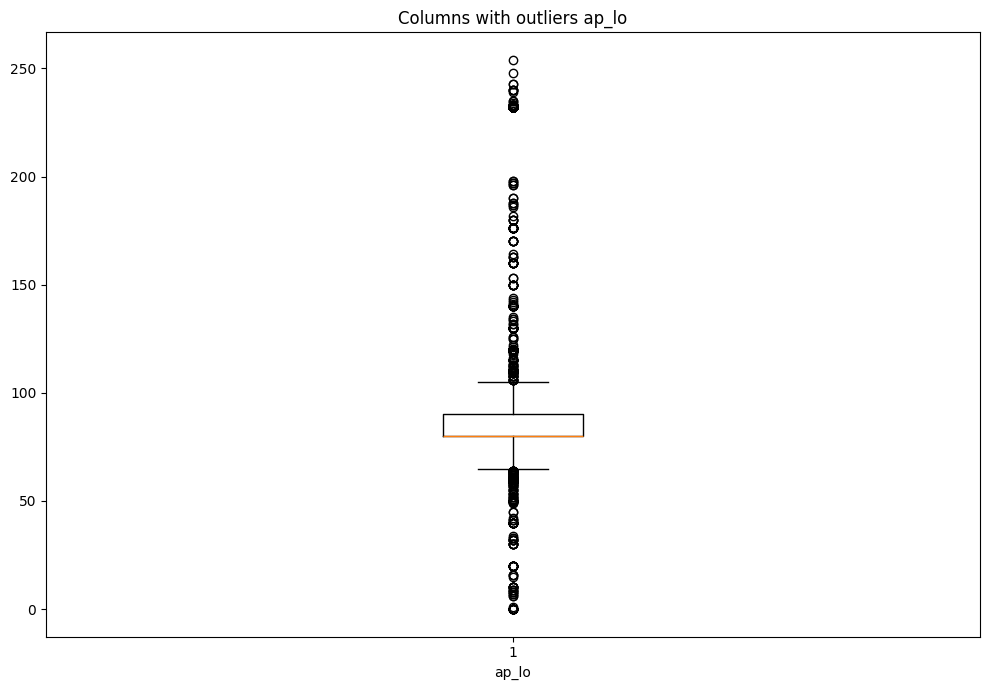

cholesterol ---------->


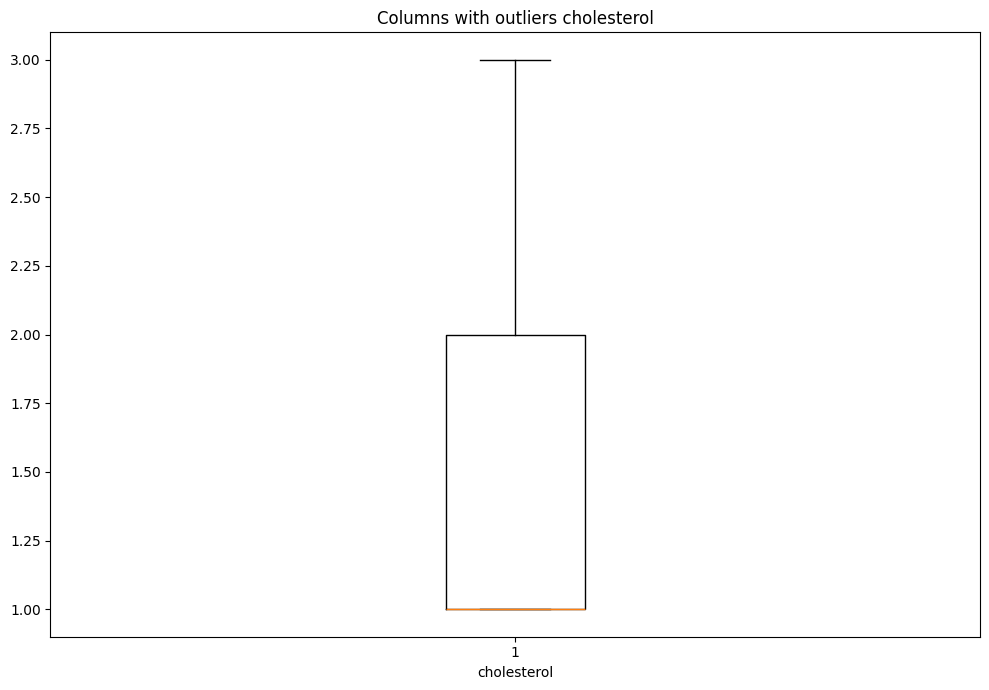

gluc ---------->


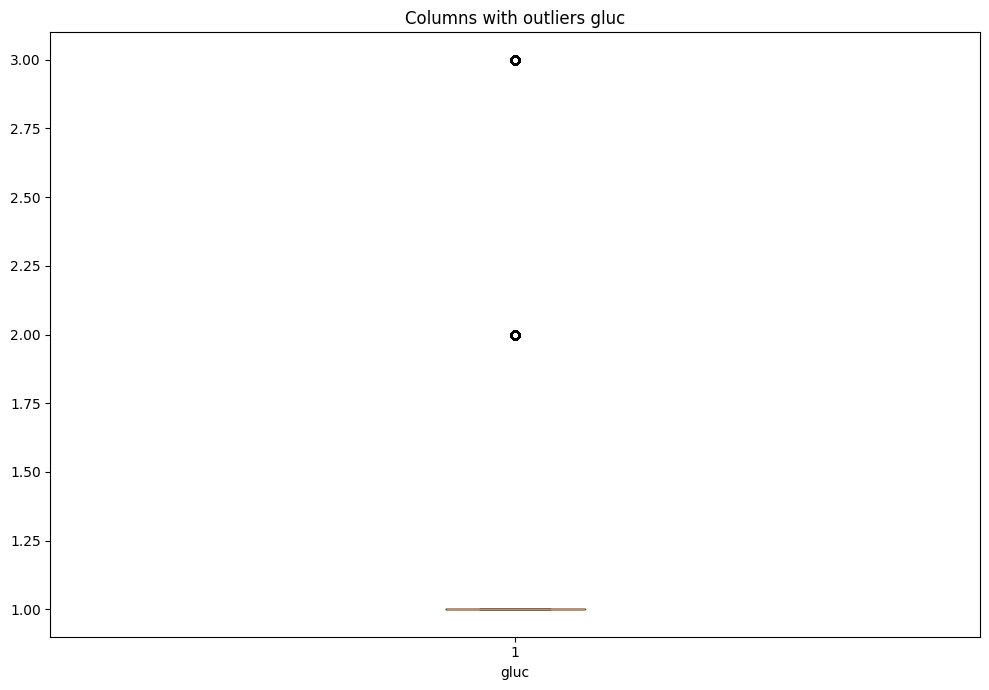

smoke ---------->


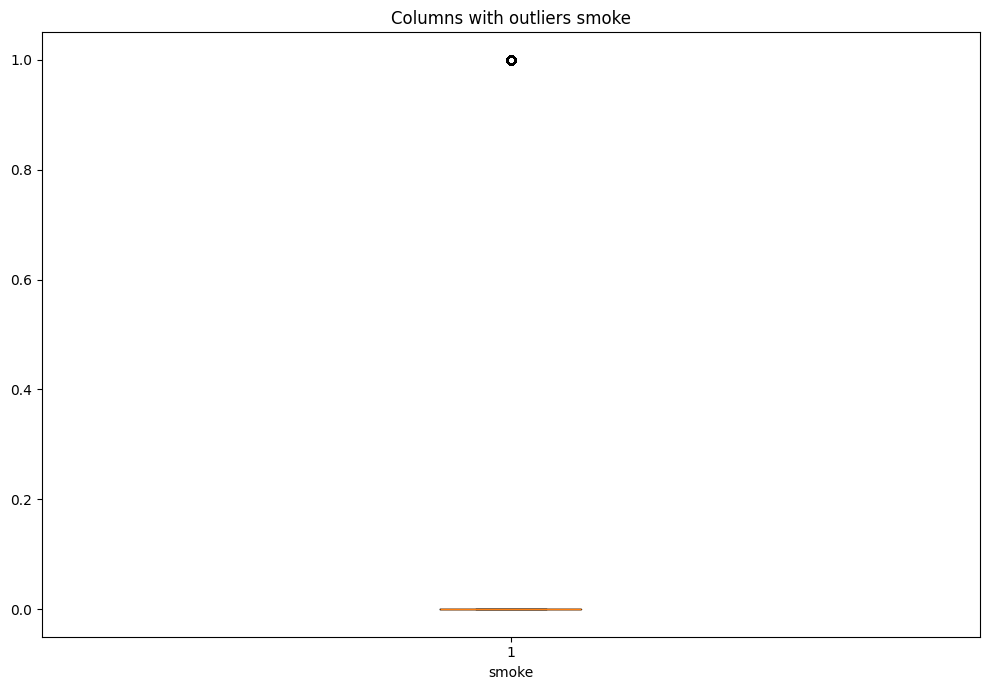

alco ---------->


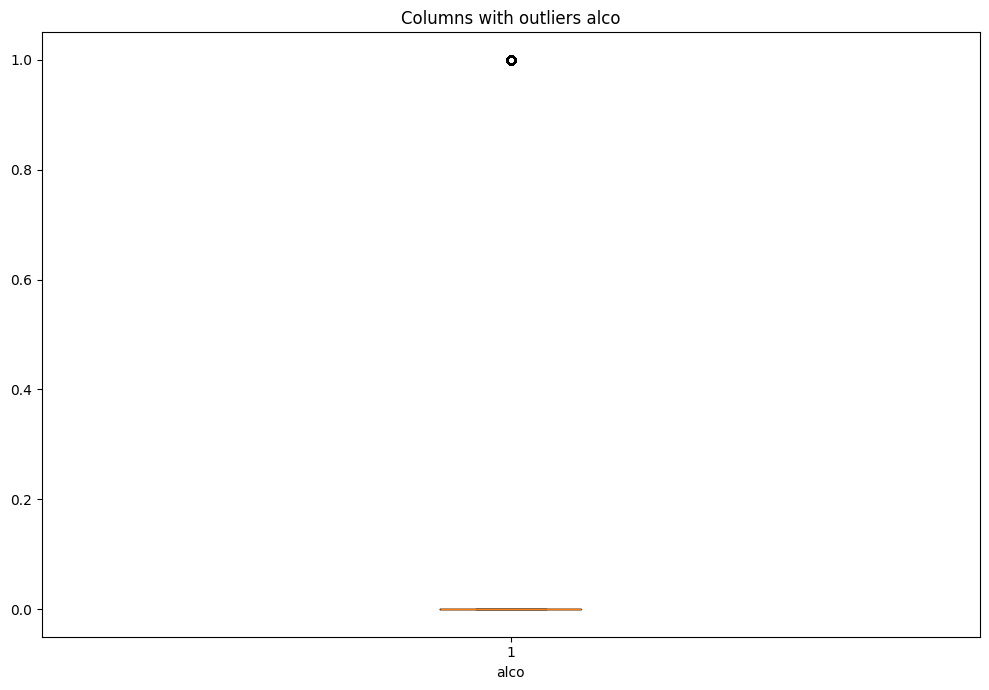

active ---------->


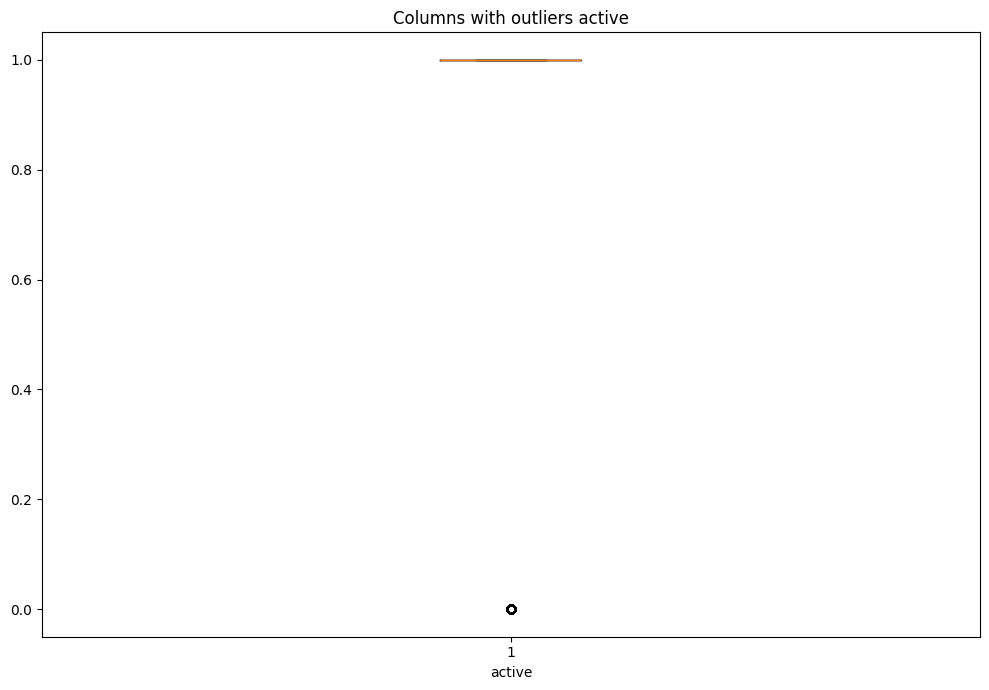

cardio ---------->


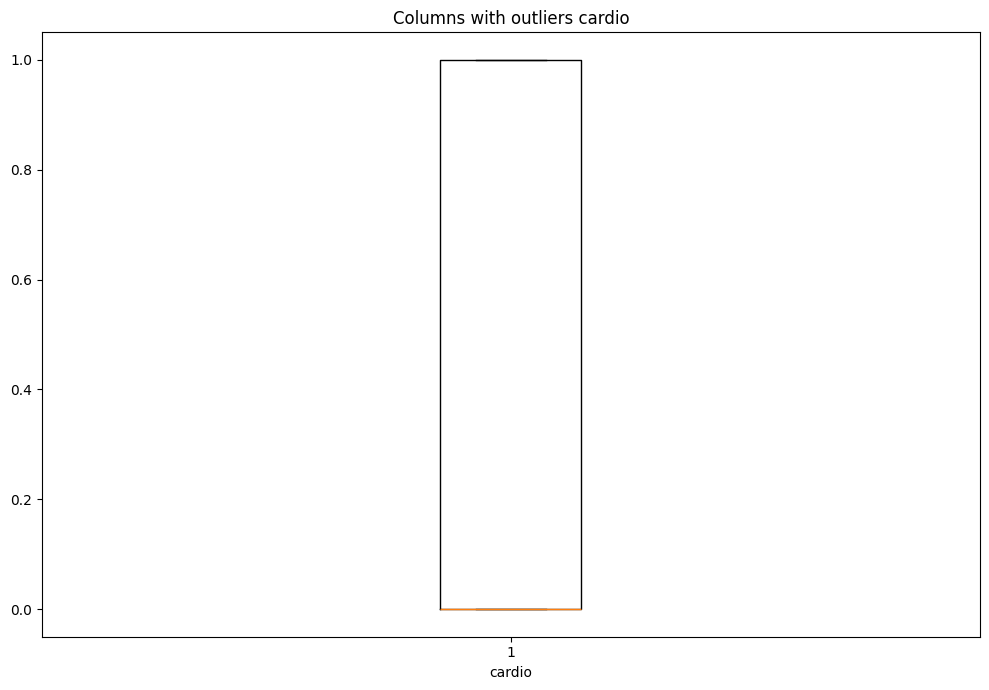

In [15]:
for col in df.columns:
    print(col + " ---------->")
    
    plt.figure(figsize =(10, 7))
    plt.boxplot(df[col])

    plt.title(f"Columns with outliers {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Columns with outliers are height, weight, ap_hi, ap_lo

age: Skewness = -0.2847 → Roughly Symmetric


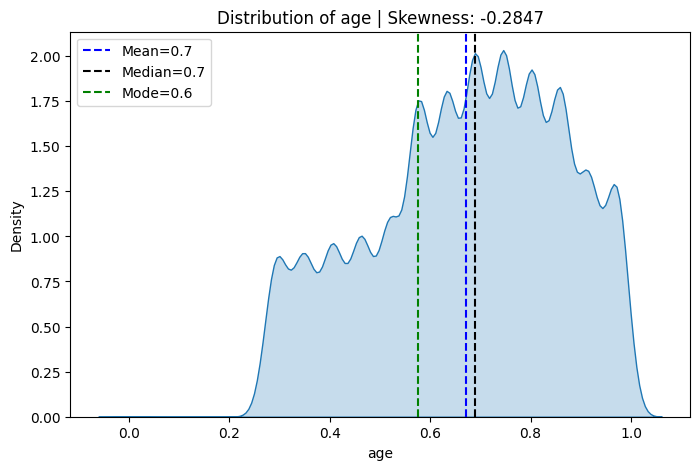

height: Skewness = -0.2341 → Roughly Symmetric


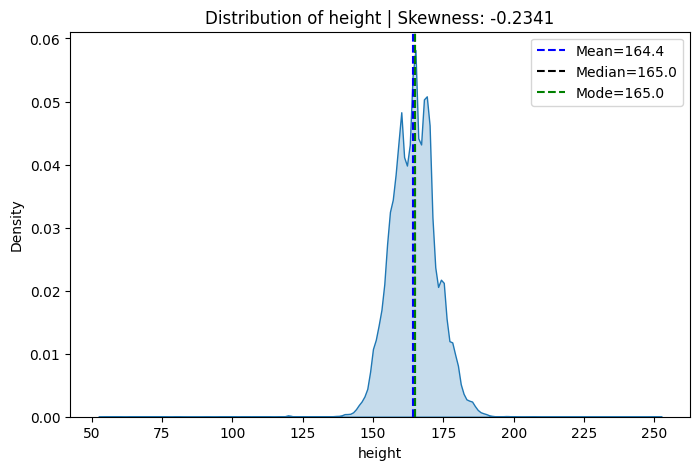

weight: Skewness = 0.4597 → Roughly Symmetric


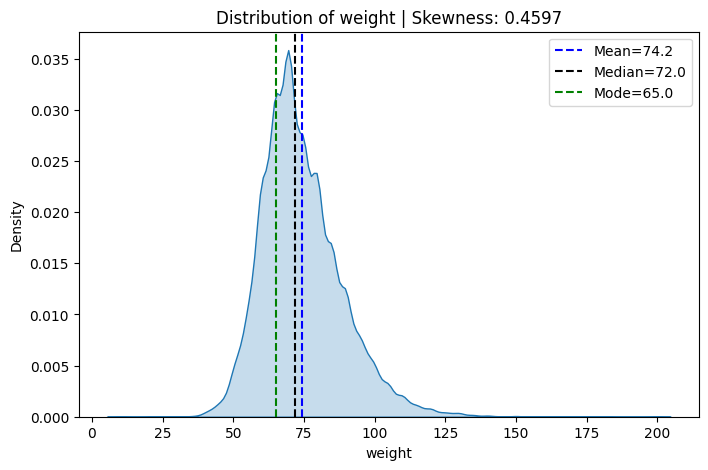

ap_hi: Skewness = 1.1139 → Positively Skewed


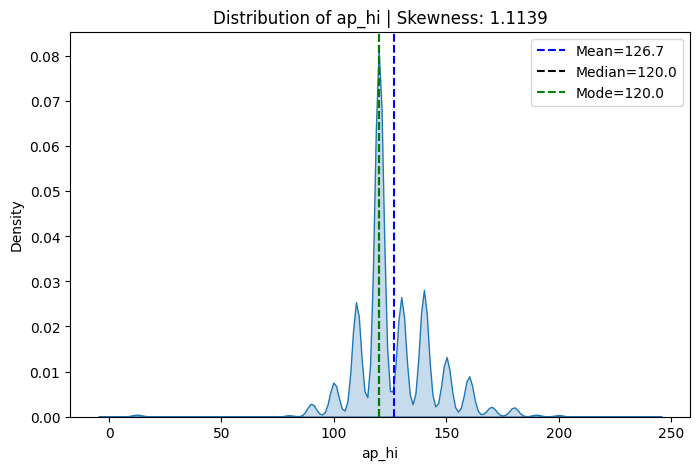

ap_lo: Skewness = 0.4730 → Roughly Symmetric


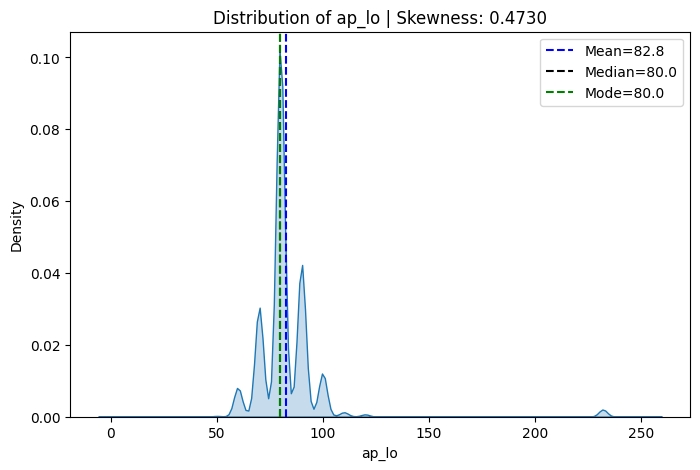

In [16]:
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in numerical_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    std_val = df[col].std()
    mode_val = df[col].mode()[0]

    pearson_skewness = (3 * (mean_val - median_val)) / std_val

    if pearson_skewness > 0.5:
        skew_type = "Positively Skewed"
    elif pearson_skewness < -0.5:
        skew_type = "Negatively Skewed"
    else:
        skew_type = "Roughly Symmetric"

    print(f"{col}: Skewness = {pearson_skewness:.4f} → {skew_type}")

    plt.figure(figsize=(8, 5))
    sns.kdeplot(df[col], fill=True)
    plt.axvline(mean_val, color='blue', linestyle='--', label=f"Mean={mean_val:.1f}")
    plt.axvline(median_val, color='black', linestyle='--', label=f"Median={median_val:.1f}")
    plt.axvline(mode_val, color='green', linestyle='--', label=f"Mode={mode_val:.1f}")
    plt.title(f"Distribution of {col} | Skewness: {pearson_skewness:.4f}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Preprocess Data

In [17]:
#Removing Outliers
df = df[df['age'] >= 0.06]
df = df[df['ap_hi'].between(80, 180)]
df = df[df['ap_lo'].between(60, 120)]
df = df[df['weight'].between(45, 105)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[df['height'].between(145, 190)]

In [18]:
df = df.drop_duplicates()

# Feature Engineering

In [19]:
df['bmi'] = df['weight'] / (df['height'] / 100) ** 2

In [20]:
#Save version
train_ver1 = df.copy()

In [ ]:
df[['age', 'height', 'weight', 'ap_hi', 'ap_lo']].describe()

In [ ]:
##Saving another version
train_df2 = df.copy()

In [ ]:
train_df2['age_band']    = pd.qcut(train_df2['age'], q=4, labels=['young','mid_age','senior','elderly'])
train_df2['weight_band'] = pd.qcut(train_df2['weight'], q=4, labels=['light','medium','heavy','very_heavy'])

train_df2['height_band'] = pd.cut(train_df2['height'], bins=[145,155,165,175,190], labels=['very_short','short','medium','tall'])
train_df2['ap_hi_band']  = pd.cut(train_df2['ap_hi'], bins=[80,120,130,140,180], labels=['normal','elevated','high_1','high_2'])
train_df2['ap_lo_band']  = pd.cut(train_df2['ap_lo'], bins=[60,80,90,120], labels=['normal','high_1','high_2'])
train_df2['bmi_band']    = pd.cut(train_df2['bmi'], bins=[0,18.5,25,30,60], labels=['underweight','normal','overweight','obese'])

train_df2 = train_df2.drop(columns=['age','height','weight','ap_hi','ap_lo','bmi'])

In [ ]:
train_df3 = df.copy()

In [ ]:
# %   → gives the remainder
# //  → gives the quotient (integer division)

train_df3['ap_hi_hundreds'] = (train_df3['ap_hi'] // 100).astype(int)
train_df3['ap_hi_tens']     = (train_df3['ap_hi'] % 100 // 10).astype(int)
train_df3['ap_hi_units']    = (train_df3['ap_hi'] % 10).astype(int)

# AP_LO digits (values like 60-120)
train_df3['ap_lo_hundreds'] = (train_df3['ap_lo'] // 100).astype(int)
train_df3['ap_lo_tens']     = (train_df3['ap_lo'] % 100 // 10).astype(int)
train_df3['ap_lo_units']    = (train_df3['ap_lo'] % 10).astype(int)

# Height digits (values like 145-190)
train_df3['height_hundreds'] = (train_df3['height'] // 100).astype(int)
train_df3['height_tens']     = (train_df3['height'] % 100 // 10).astype(int)
train_df3['height_units']    = (train_df3['height'] % 10).astype(int)

# Weight digits (values like 45-105)
train_df3['weight_tens']  = (train_df3['weight'] // 10).astype(int)
train_df3['weight_units'] = (train_df3['weight'] % 10).astype(int)

train_df3['age_d1'] = (train_df3['age'] * 10).astype(int) % 10  
train_df3['age_d2'] = (train_df3['age'] * 100).astype(int) % 10 

train_df3 = train_df3.drop(columns=['age','height','weight','ap_hi','ap_lo','bmi'])

In [ ]:
train_df4 = train_df3.copy()

In [ ]:
train_df4 = train_df3.astype(str).astype('category')

In [ ]:
df.head()

In [24]:
X = df.drop("cardio", axis=1)   # features
y = df["cardio"]                # label

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Encode
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
encoder = ce.TargetEncoder(cols=cat_cols)
encoder.fit(X_train, y_train)

# Transform both
X_train_encoded = encoder.transform(X_train)
X_test_encoded  = encoder.transform(X_test)

# Reconstruct full df with target column
train_df5 = pd.concat([
    pd.concat([X_train_encoded, y_train], axis=1),
    pd.concat([X_test_encoded, y_test], axis=1)
]).sort_index() 

In [ ]:
train_df5 = df.copy()


num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

function_set = ['add', 'sub', 'mul', 'div', 'sqrt', 'log', 'abs']

gp = SymbolicTransformer(
    generations=5,          # how many evolution rounds
    population_size=1000,   # how many candidates per round
    hall_of_fame=100,       # top candidates kept
    n_components=10,        # number of new features to create
    function_set=function_set,
    parsimony_coefficient=0.001,
    max_samples=0.9,
    random_state=42,
    verbose=1,
    n_jobs=-1               # use all CPU cores
)

gp.fit(X[num_cols], y)
gp_features = gp.transform(X[num_cols])

# Add new features to df
gp_df = pd.DataFrame(
    gp_features,
    columns=[f'gp_{i}' for i in range(gp_features.shape[1])],
    index=X.index
)

train_df5 = pd.concat([train_df5, gp_df], axis=1)

# Model Training

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Model params ──────────────────────────────────────
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'auc',
    'random_state': 42,
    'verbosity': 0
}

lgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1
}
realmlp_params = {
    'device': 'cuda',
    'random_state': 42,
    'n_epochs': 100,
    'batch_size': 128,
    'n_ens': 8,
    'val_metric_name': '1-auc_ovr',
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}


# ── OOF functions ─────────────────────────────────────
def train_oof_xgb(X, y, params, skf):
    # XGBoost cant handle category dtype → convert to int
    X = X.copy()
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].cat.codes

    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


def train_oof_lgb(X, y, params, skf):
    # LightGBM handles category dtype natively ✅
    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = LGBMClassifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


def train_oof_realmlp(X, y, params, skf):
    # RealMLP cant handle category dtype → convert to int
    X = X.copy()
    cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
    for col in cat_cols:
        X[col] = X[col].cat.codes

    oof_preds = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = RealMLP_TD_Classifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y, oof_preds)
    return oof_preds, auc


# ── Main training function ────────────────────────────
def train_all_versions(version_dict):
    results = {}

    for version_name, data in version_dict.items():
        print(f'\n{"="*50}')
        print(f'  Version: {version_name}')
        print(f'{"="*50}')

        X = data.drop(columns=['cardio'])
        y = data['cardio'].astype(int) 

        # XGBoost
        print(f'XGBoost → training...')
        _, auc = train_oof_xgb(X, y, xgb_params, skf)
        results[f'{version_name}_xgb'] = auc
        print(f'XGBoost → AUC: {auc:.6f}')

        # LightGBM
        print(f'LightGBM → training...')
        _, auc = train_oof_lgb(X, y, lgb_params, skf)
        results[f'{version_name}_lgb'] = auc
        print(f'LightGBM → AUC: {auc:.6f}')

        # RealMLP
        print(f'RealMLP → training...')
        _, auc = train_oof_realmlp(X, y, realmlp_params, skf)
        results[f'{version_name}_realmlp'] = auc
        print(f'RealMLP → AUC: {auc:.6f}')

    # ── Summary ──────────────────────────────────────
    print(f'\n\n{"="*50}')
    print('FINAL SUMMARY')
    print(f'{"="*50}')
    results_df = pd.DataFrame(
        list(results.items()),
        columns=['Model_Version', 'AUC']
    ).sort_values('AUC', ascending=False)

    print(results_df.to_string(index=False))
    return results_df


# ── Run ───────────────────────────────────────────────
versions = {
    'v1': train_ver1,
    'v2': train_df2,
    'v3': train_df3,
    'v4': train_df4,
    'v5': train_df5,
}

results_df = train_all_versions(versions)

In [ ]:
import pickle

# Save the best model — V1 RealMLP
# First train it on full data
X = train_ver1.drop(columns=['cardio'])
y = train_ver1['cardio'].astype(int)

best_model = RealMLP_TD_Classifier(**realmlp_params)
best_model.fit(X, y)

# Save model
with open('best_model_v1_realmlp.pkl', 'wb') as f:
    pickle.dump(best_model, f)


# Save the data versions too
train_ver1.to_csv('train_v1.csv', index=False)

print('All saved!')

In [ ]:
import pickle
# Load model
with open('cardiac_failure_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

print('Loaded successfully!')

Baseline Model (Accuracy) = 0.73

It imporved from 0.73 to 0.80 which is huge and good so now imporve that model to get maybe more score

In [ ]:
train_ver1['bp_diff']    = train_ver1['ap_hi'] - train_ver1['ap_lo']
train_ver1['bp_ratio']   = train_ver1['ap_hi'] / train_ver1['ap_lo']
train_ver1['bmi_age']    = train_ver1['bmi'] * train_ver1['age']
train_ver1['chol_age']   = train_ver1['cholesterol'] * train_ver1['age']
train_ver1['smoke_age']  = train_ver1['smoke'] * train_ver1['age']
train_ver1['alco_age']   = train_ver1['alco'] * train_ver1['age']
train_ver1['active_bmi'] = train_ver1['active'] * train_ver1['bmi']

In [ ]:
X = train_ver1.drop(columns=['cardio'])
y = train_ver1['cardio'].astype(int)


In [ ]:
realmlp_params = {
    'device': 'cuda',
    'random_state': 42,
    'n_epochs': 100,
    'batch_size': 128,
    'n_ens': 8,
    'val_metric_name': '1-auc_ovr',
    'use_early_stopping': True,
    'early_stopping_additive_patience': 20,
    'early_stopping_multiplicative_patience': 1,
    'act': "mish",
    'embedding_size': 8,
    'first_layer_lr_factor': 0.5962121993798933,
    'hidden_sizes': "rectangular",
    'hidden_width': 384,
    'lr': 0.04,
    'ls_eps': 0.011498317194338772,
    'ls_eps_sched': "coslog4",
    'max_one_hot_cat_size': 18,
    'n_hidden_layers': 4,
    'p_drop': 0.07301419697186451,
    'p_drop_sched': "flat_cos",
    'plr_hidden_1': 16,
    'plr_hidden_2': 8,
    'plr_lr_factor': 0.1151437622270563,
    'plr_sigma': 2.3316811282666916,
    'scale_lr_factor': 2.244801835541429,
    'sq_mom': 1.0 - 0.011834054955582318,
    'wd': 0.02369230879235962,
}

In [ ]:
oof_preds = np.zeros(len(y))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model = RealMLP_TD_Classifier(**realmlp_params)
    model.fit(X_train, y_train)
    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

auc = roc_auc_score(y, oof_preds)
print(f'With domain features AUC: {auc:.6f}')
print(f'Baseline AUC:             0.800034')
print(f'Improvement:              {auc - 0.800034:+.6f}')

This clearly shows that adding more features is not improving our model rather it is decreasing.

So now lets move to step of hyperparameter tuning

In [ ]:
import optuna

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        # FIXED 
        'device':                                 'cuda',
        'random_state':                           42,
        'val_metric_name':                        '1-auc_ovr',
        'use_early_stopping':                     True,
        'early_stopping_additive_patience':       20,
        'early_stopping_multiplicative_patience': 1,
        'act':                                    'mish',
        'ls_eps':                                 0.011498317194338772,
        'ls_eps_sched':                           'coslog4',
        'p_drop_sched':                           'flat_cos',
        'hidden_sizes':                           'rectangular',

        # TUNE 
        'lr':              trial.suggest_float('lr', 0.01, 0.1, log=True),
        'embedding_size':  trial.suggest_int('embedding_size', 7, 9),
        'hidden_width':    trial.suggest_int('hidden_width', 256, 512),  # ← merged both into one range
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 2, 6),
        'p_drop':          trial.suggest_float('p_drop', 0.0, 0.3),
        'batch_size':      trial.suggest_categorical('batch_size', [64, 128, 256]),
        'wd':              trial.suggest_float('wd', 0.001, 0.1, log=True),
        'n_ens':           trial.suggest_categorical('n_ens', [4, 8, 16]),
        'n_epochs':        trial.suggest_int('n_epochs', 50, 200),
    }

    oof_preds = np.zeros(len(y))

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = RealMLP_TD_Classifier(**params)
        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y, oof_preds)


# Run Optuna 
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Results 
print(f'Best AUC:    {study.best_value:.6f}')
print(f'Baseline:    0.800034')
print(f'Improvement: {study.best_value - 0.800034:+.6f}')
print(f'\nBest params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

As we can see, hyperparameter tuning is not improving my model. This is likely because the parameters I used were already tuned and achieved 3rd place in the Kaggle competition, so they may not improve further.

In [ ]:
import pickle
# Load model
with open('cardiac_failure_model.pkl', 'rb') as f:
    model = pickle.load(f)

print('Loaded successfully!')

In [ ]:
#Exlainable AI
import shap

In [26]:
X = train_ver1.drop(columns=['cardio'])
y = train_ver1['cardio'].astype(int)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  0%|          | 0/50 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

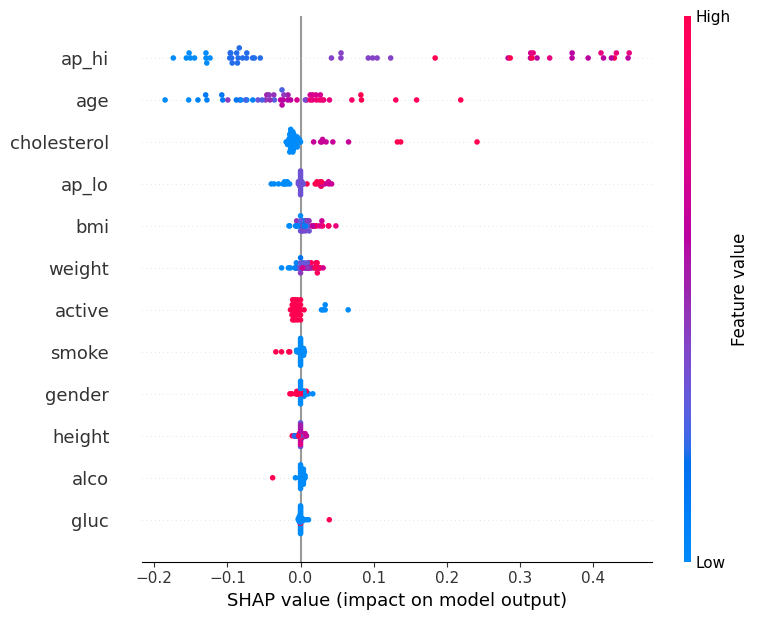

In [29]:
def model_predict(data):
    df_input = pd.DataFrame(data, columns=X_test.columns)
    return model.predict_proba(df_input)[:, 1]

background = shap.sample(X_test, 50)
test_sample = X_test.iloc[:50]

explainer = shap.KernelExplainer(model_predict, background)
shap_values = explainer.shap_values(test_sample, nsamples=100)

# Plot 1 - Summary
shap.summary_plot(shap_values, test_sample)

In [30]:
explainer = shap.KernelExplainer(
    lambda x: model.predict_proba(pd.DataFrame(x, columns=X_test.columns))[:, 1],
    shap.sample(X_test, 50)
)

shap_vals = explainer.shap_values(X_test.iloc[:200], nsamples=100)

np.save('shap_values.npy', shap_vals)
X_test.iloc[:200].to_csv('X_test.csv', index=False)
print("Saved!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  0%|          | 0/200 [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experime

Saved!


In [32]:
train_ver1.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
count,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000,65846.000000
mean,0.670846,1.347614,164.432251,73.023064,126.208016,81.109407,1.355770,1.219497,0.086809,0.052076,0.804316,0.489050,27.054820
std,0.190931,0.476216,7.569196,12.119733,15.888347,9.070929,0.672194,0.565608,0.281557,0.222182,0.396729,0.499884,4.512292
min,0.269222,1.000000,145.000000,45.000000,80.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,14.527376
25%,0.531088,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,23.833005
50%,0.689199,1.000000,165.000000,71.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,26.175195
75%,0.814634,2.000000,170.000000,80.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,29.744200
max,1.000000,2.000000,190.000000,105.000000,180.000000,120.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,48.038050


In [38]:
train_ver1.shape

(65846, 13)